In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('daily_total.csv')
df.index = [datetime.strptime(x, '%Y-%m-%d') for x in df['DATE']]
df.drop('DATE', axis=1, inplace=True)
df = df[df.index >= '2022-08-10']
column = 'SECONDSSPENT'
print(0 in df[column].to_list())
df

False


,USERCOUNT,SECONDSSPENT,QUANTITY,VOLUME,WEIGHT,PRICE
2022-08-10,1,17955232,0,0.000000,0.000000,0.00
2022-08-16,15,24864,1564,5.510447,606.628000,7714.46
2022-08-17,46,648639,153271,900.823306,87245.837728,731227.04
2022-08-18,72,1535976,353781,2687.981897,247269.820740,2135600.74
2022-08-19,70,1253113,395921,2944.799061,262781.058485,2136707.30
...,...,...,...,...,...,...
2023-09-25,101,1171721,854092,2678.434373,292547.191456,1875797.61
2023-09-26,110,1249771,1016887,3483.392239,371822.547589,2318629.60
2023-09-27,104,1257222,939123,2998.222002,300263.198492,1850064.42
2023-09-28,109,1339688,1224169,3863.465093,384720.606181,2390796.27


In [4]:
# correlation matrix
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,USERCOUNT,SECONDSSPENT,QUANTITY,VOLUME,WEIGHT,PRICE
USERCOUNT,1.000000,0.320667,0.733127,0.690918,0.744108,0.434386
SECONDSSPENT,0.320667,1.000000,0.369673,0.327348,0.368531,0.209718
QUANTITY,0.733127,0.369673,1.000000,0.737310,0.876233,0.372881
VOLUME,0.690918,0.327348,0.737310,1.000000,0.942859,0.558671
WEIGHT,0.744108,0.368531,0.876233,0.942859,1.000000,0.522247
PRICE,0.434386,0.209718,0.372881,0.558671,0.522247,1.000000


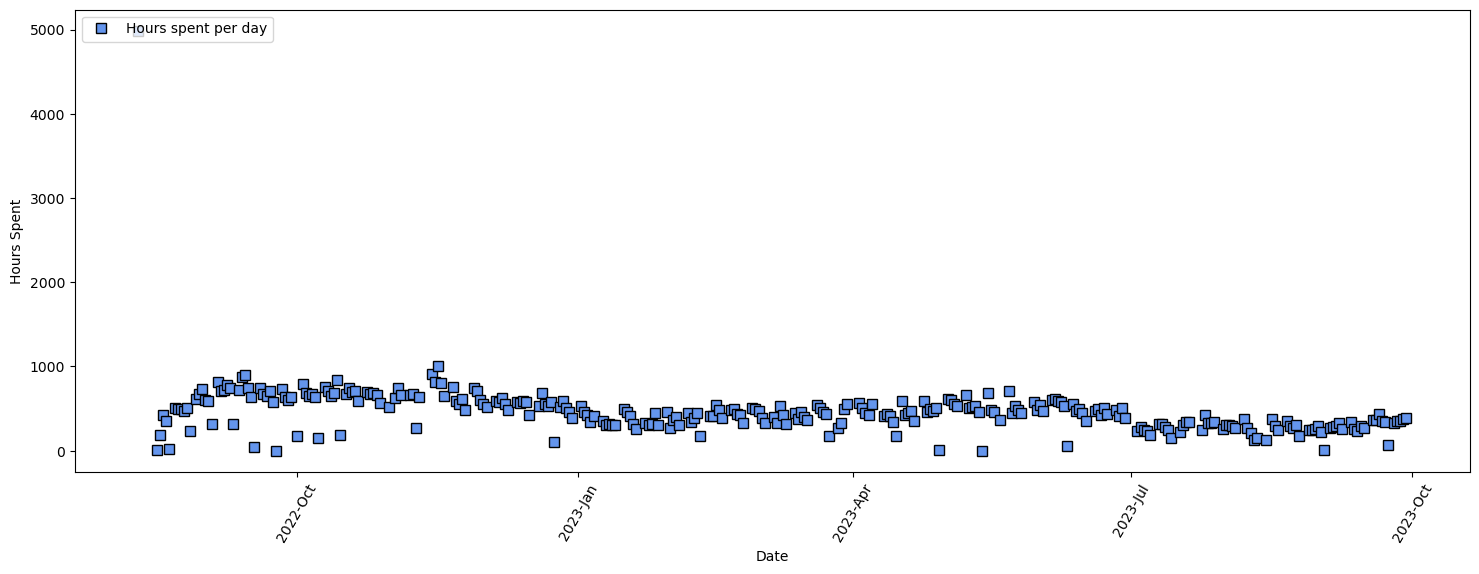

In [182]:
fig, ax = plt.subplots()
fig.set_size_inches(18, 6)
ax.plot(df.index, df[column] / 3600, linestyle='none', marker='s',
        markerfacecolor='cornflowerblue', 
        markeredgecolor='black',
        markersize=7,
        label='Hours spent per day')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
ax.set_xlabel('Date')
ax.set_ylabel('Hours Spent')
plt.xticks(rotation=60)
ax.legend(loc='upper left')

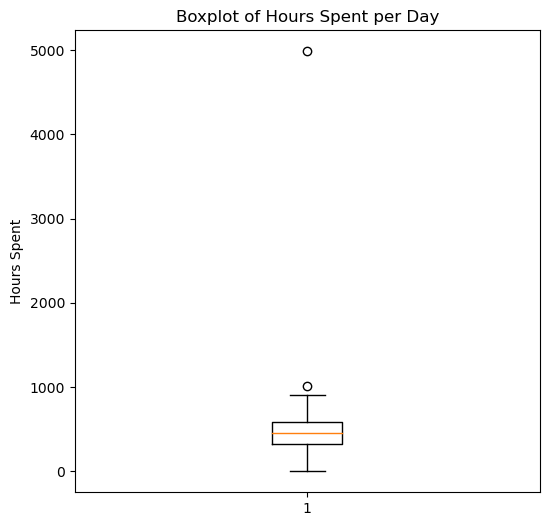

In [183]:
# boxplot of hours spent per day
fig, ax = plt.subplots()
fig.set_size_inches(6, 6)
ax.boxplot(df[column] / 3600)
ax.set_ylabel('Hours Spent')
ax.set_title('Boxplot of Hours Spent per Day')
plt.show()

In [184]:
df[column].sort_values(ascending=False).head(10)

2022-08-10    17955232
2022-11-16     3628515
2022-11-14     3272069
2022-09-14     3213480
2022-09-13     3144026
2022-10-14     3006732
2022-11-15     2951189
2022-09-05     2948984
2022-11-17     2911377
2022-10-03     2834680
Name: SECONDSSPENT, dtype: int64

In [185]:
# # remove outliers
# df = df[df['SECONDSSPENT'] / 3600 < 2000]

# fig, ax = plt.subplots()
# fig.set_size_inches(18, 6)
# ax.plot(df.index, df['SECONDSSPENT'] / 3600, linestyle='none', marker='s',
#         markerfacecolor='cornflowerblue', 
#         markeredgecolor='black',
#         markersize=7,
#         label='Hours spent per day')
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
# ax.set_xlabel('Date')
# ax.set_ylabel('Hours Spent')
# plt.xticks(rotation=60)
# ax.legend(loc='upper left')

In [186]:
corr_list = []

for i in range(1, len(df) - 1):
    corr_list.append(np.corrcoef(df[column][i:], df[column][: -i])[0, 1])

# index and correlation coefficient dataframe
corr_df = pd.DataFrame({'Lag': list(range(1, len(df) - 1)), 'Correlation': corr_list})
corr_df = corr_df.sort_values(by='Correlation', ascending=False)
print(corr_df.head(10).to_string(index=False))

 Lag  Correlation
   6     0.364674
 233     0.351293
 291     0.345602
  18     0.307066
  12     0.304645
 265     0.278341
  25     0.277149
  14     0.269017
  24     0.265949
 259     0.260127


In [187]:
def find_period(signal, corr_threshold=0.2):
    acf = np.correlate(signal, signal, 'full')[-len(signal):]
    inflection = np.diff(np.sign(np.diff(acf)))
    peaks = (inflection < 0).nonzero()[0] + 1
    if len(peaks) == 0:
        print('No seasonality found')
        return 1, 0
    period = peaks[acf[peaks].argmax()]
    corr = np.corrcoef(df[column][period:], df[column][: -period])[0, 1]
    if corr < corr_threshold or period == 1:
        print('No seasonality found')
        return 1, corr
    return period, corr

period, corr = find_period(df[column])
print('Period:', period, '\nCorrelation:', corr)

Period: 6 
Correlation: 0.36467427746857994


In [188]:
# log transformation
df_log = df.copy()
df_log[column] = df_log[column].replace(0, np.nan).interpolate(method='spline', order=3)
df_log[column] = np.log(df_log[column])

In [189]:
# deseaonalize
df_log['Seasonal'] = seasonal_decompose(df_log[column], model='additive', period=period).seasonal
df_log['DS'] = seasonal_decompose(df_log[column], model='additive', period=period).trend

# linear regression with deseasonalized SECONDSSPENT
reg_df = df_log[df_log['DS'].notna()]
endog = np.array(reg_df['DS'])
exog = sm.add_constant(np.array(reg_df.index.dayofyear))
model = sm.OLS(endog, exog)
results = model.fit()
# print(results.summary())

initial_level = results.params[0]
initial_trend = results.params[1]
df_log['DS'] = initial_level + initial_trend * np.array(df_log.index.dayofyear)
df_log['Seasonal Factor'] = df_log[column] / df_log['DS']

initial_seasonal = []
if period == 1:
    initial_seasonal = [1]
else:
    for i in range(period):
        initial_seasonal.append(df_log.iloc[i::period].mean()['Seasonal Factor'])

print(initial_level)
print(initial_trend)
print(initial_seasonal)


13.998551531338894
0.0007974298890779006
[1.0101592992031774, 1.0082206169722134, 1.0041431072283848, 0.9973260138771978, 0.9986877487591869, 0.978653862800062]


In [190]:
seasonal_periods = period
alpha = 0.5
beta = 0.01
gamma = 0.01

winters_model = ExponentialSmoothing(
    df_log[column],
    trend="add",
    seasonal="mul",
    seasonal_periods=seasonal_periods,
    initialization_method="known",
    initial_level=initial_level,
    initial_trend=initial_trend,
    initial_seasonal=initial_seasonal
).fit(smoothing_level=alpha,
      smoothing_trend=beta,
      smoothing_seasonal=gamma,
      )

last_day = df_log.index[-1]

num_periods = period
df_log["FORECAST"] = winters_model.fittedvalues
forecast = pd.DataFrame(
    {'FORECAST': list(winters_model.forecast(num_periods))},
    index=pd.date_range(start=last_day + pd.DateOffset(days=1), periods=num_periods, freq='D')
)

df_forecast = df_log.append(forecast)
df_forecast[[column,'FORECAST']] = np.exp(df_forecast[[column,'FORECAST']])
df_forecast.tail(period*2)

,USERCOUNT,SECONDSSPENT,QUANTITY,VOLUME,WEIGHT,PRICE,Seasonal,DS,Seasonal Factor,FORECAST
2023-09-23,1.0,227385.0,0.0,0.000000,0.000000,0.00,0.089603,14.210668,0.867968,1.656529e+06
2023-09-25,101.0,1171721.0,854092.0,2678.434373,292547.191456,1875797.61,0.197265,14.212263,0.983234,5.963476e+05
2023-09-26,110.0,1249771.0,1016887.0,3483.392239,371822.547589,2318629.60,0.067608,14.213060,0.987716,7.837436e+05
2023-09-27,104.0,1257222.0,939123.0,2998.222002,300263.198492,1850064.42,-0.030213,14.213858,0.988079,9.357150e+05
2023-09-28,109.0,1339688.0,1224169.0,3863.465093,384720.606181,2390796.27,-0.010426,14.214655,0.992493,1.123836e+06
2023-09-29,107.0,1381580.0,1109442.0,3556.001516,377380.162562,2196789.75,-0.313838,14.215452,0.994603,9.156812e+05
2023-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.651946e+06
2023-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.663605e+06
2023-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.562009e+06
2023-10-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.478038e+06


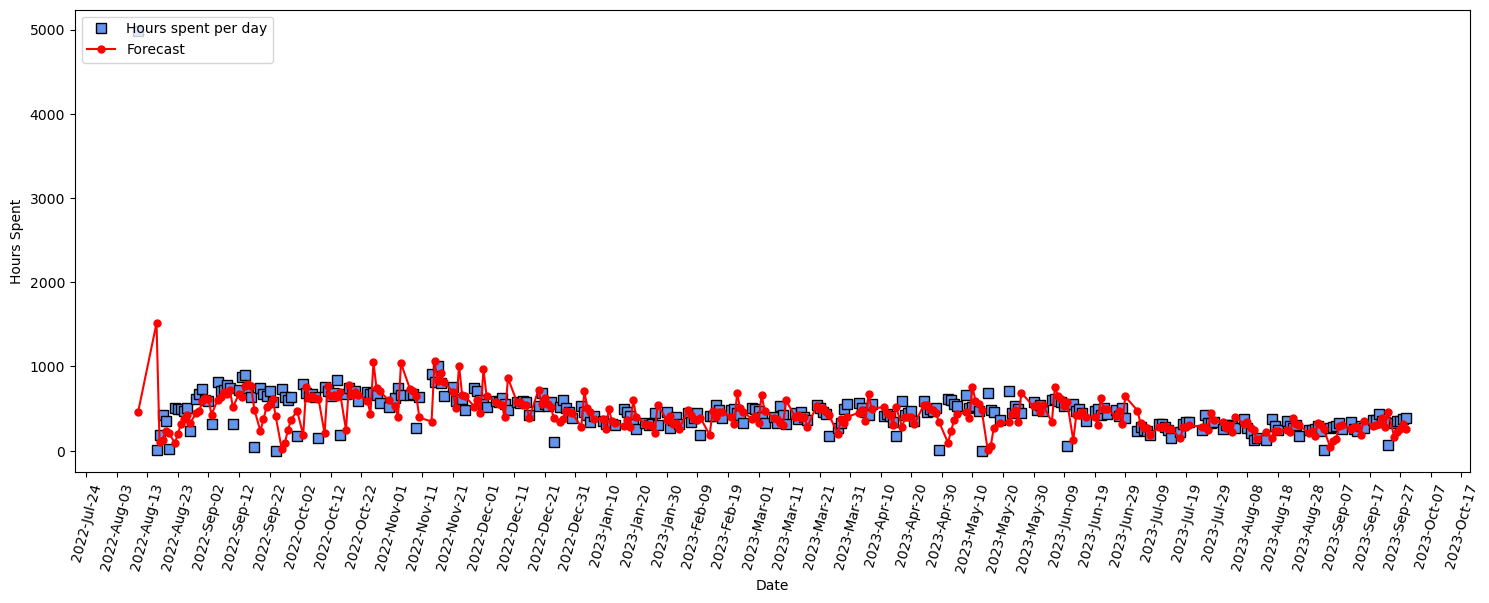

In [191]:
last_day = df.index[-1]
# df_plot = df_forecast[df_forecast.index >= last_day - pd.to_timedelta("365day")]
df_plot = df_forecast[df_forecast.index <= last_day]

fig, ax = plt.subplots()
fig.set_size_inches(18, 6)
ax.plot(df_plot.index, df_plot[column] / 3600, 
        linestyle='none', 
        marker='s',
        markerfacecolor='cornflowerblue', 
        markeredgecolor='black',
        markersize=7,
        label='Hours spent per day')
ax.plot(df_plot.index, df_plot['FORECAST'] / 3600, 
        linestyle='-',
        marker='o',
        markersize=5,
        color='red',
        label='Forecast')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
ax.set_xlabel('Date')
ax.set_ylabel('Hours Spent')
plt.xticks(rotation=75)
ax.legend(loc='upper left')
plt.show()

In [192]:
# mean absolute error
test_size = int(len(df_plot) * 0.2)
test = df_plot[-test_size:]
mae = np.mean(np.abs(test[column] - test['FORECAST'])) /3600
print('MAE: {:.3f}'.format(mae))

# root mean squared error
mse = np.sqrt(np.mean(((test[column] - test['FORECAST'])) ** 2)) / 3600
print('RMSE: {:.3f}'.format(mse))

MAE: 83.531
RMSE: 107.325


In [193]:
import numpy as np
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing


def _get_period(data: pd.Series, corr_threshold: float = 0.2):
    acf = np.correlate(data, data, 'full')[-len(data):]
    inflection = np.diff(np.sign(np.diff(acf)))
    peaks = (inflection < 0).nonzero()[0] + 1
    if len(peaks) == 0:
        print('No seasonality found')
        return 1, 0
    period = peaks[acf[peaks].argmax()]
    corr = np.corrcoef(data[period:], data[: -period])[0, 1]
    if corr < corr_threshold or period == 1:
        print('No seasonality found')
        return 1, corr
    return period, corr


def _get_initial_params(df: pd.DataFrame, column: str, log: bool = True):
    period, corr = _get_period(df[column])

    df_log = df.copy()
    df_log[column] = df_log[column].replace(0, np.nan).interpolate(method='spline', order=3)
    if log:
        df_log[column] = np.log(df_log[column])

    # deseaonalize
    df_log['Seasonal'] = seasonal_decompose(df_log[column], model='additive', period=period).seasonal
    df_log['DS'] = seasonal_decompose(df_log[column], model='additive', period=period).trend

    # linear regression with deseasonalized SECONDSSPENT
    reg_df = df_log[df_log['DS'].notna()]
    endog = np.array(reg_df['DS'])
    exog = sm.add_constant(np.array(reg_df.index.dayofyear))
    model = sm.OLS(endog, exog)
    results = model.fit()
    # print(results.summary())

    initial_level = results.params[0]
    initial_trend = results.params[1]
    df_log['DS'] = initial_level + initial_trend * np.array(df_log.index.dayofyear)
    df_log['Seasonal Factor'] = df_log[column] / df_log['DS']

    initial_seasonal = []
    if period == 1:
        initial_seasonal = [1]
    else:
        for i in range(period):
            initial_seasonal.append(df_log.iloc[i::period].mean()['Seasonal Factor'])
    
    return period, initial_level, initial_trend, initial_seasonal


def forecast(df: pd.DataFrame, 
            column: str, 
            log: bool = True,
            alpha: float = 0.5, 
            beta: float =  0.01, 
            gamma: float = 0.01):
    
    period, initial_level, initial_trend, initial_seasonal = _get_initial_params(df, column, log)
    print('Period: {}'.format(period))
    print('Initial Level: {}'.format(initial_level))
    print('Initial Trend: {}'.format(initial_trend))
    print('Initial Seasonal: {}'.format(initial_seasonal))
    
    df_log = df.copy()
    df_log[column] = df_log[column].replace(0, np.nan).interpolate(method='spline', order=3)
    if log:
        df_log[column] = np.log(df_log[column])
    
    if period != 1:
        winters_model = ExponentialSmoothing(
        df_log[column],
        trend="add",
        seasonal="mul",
        seasonal_periods=period,
        initialization_method="known",
        initial_level=initial_level,
        initial_trend=initial_trend,
        initial_seasonal=initial_seasonal
    ).fit(smoothing_level=alpha,
        smoothing_trend=beta,
        smoothing_seasonal=gamma,
        )
    else:
        winters_model = ExponentialSmoothing(
        df_log[column],
        trend="add",
        seasonal=None,
        initialization_method="known",
        initial_level=initial_level,
        initial_trend=initial_trend
    ).fit(smoothing_level=alpha,
        smoothing_trend=beta
        )

    last_day = df_log.index[-1]
    num_periods = period
    df_log["FORECAST"] = winters_model.fittedvalues
    forecast = pd.DataFrame(
        {'FORECAST': list(winters_model.forecast(num_periods))},
        index=pd.date_range(start=last_day + pd.DateOffset(days=1), periods=num_periods, freq='D')
    )

    df_forecast = df_log.append(forecast)
    if log:
        df_forecast[[column,'FORECAST']] = np.exp(df_forecast[[column,'FORECAST']])
    print(df_forecast.tail(period*2))

    return df_forecast


def plot_forecast(df: pd.DataFrame, column: str, title: str = ''):
    df_forecast = forecast(df, column)
    # df_plot = df_forecast[df_forecast.index >= '2022-08-10']
    df_plot = df_forecast

    test_size = int(len(df_plot) * 0.2)
    test = df_plot[-test_size:]
    mae = np.mean(np.abs(test[column] - test['FORECAST'])) / 3600
    print('MAE: {:.3f}'.format(mae))

    fig, ax = plt.subplots()
    fig.set_size_inches(18, 6)
    ax.plot(df_plot.index, df_plot[column] / 3600, 
            linestyle='none', 
            marker='s',
            markerfacecolor='cornflowerblue', 
            markeredgecolor='black',
            markersize=7,
            label='Hours spent per day')
    ax.plot(df_plot.index, df_plot['FORECAST'] / 3600, 
            linestyle='-',
            marker='o',
            markersize=5,
            color='red',
            label='Forecast')
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
    ax.set_xlabel('Date')
    ax.set_ylabel('Hours Spent')
    plt.xticks(rotation=75)
    ax.legend(loc='upper left')
    plt.show()



True
DD
Period: 69
Initial Level: 10.436396723477277
Initial Trend: -0.00040203779713041024
Initial Seasonal: [1.1546310079504098, 0.9487050115309824, 0.818409514868657, 0.9110654198538063, 1.0154252924318778, 0.9262929925038724, 0.9836935081823756, 1.0245301644610958, 1.0000906985354634, 1.0044604469495169, 1.010584520514819, 0.9008275015505782, 0.9790792638167606, 0.8850446875081708, 1.035429936432882, 0.8590358929507985, 0.9258075397912988, 1.0633722873013167, 1.0064956306478032, 1.0778745046511036, 1.0666120867985436, 1.1329069423604656, 0.9524795429559147, 1.05473665521198, 0.9416343152880589, 0.9784879463347699, 1.023675754913796, 0.9883124286387555, 1.0489641601359314, 0.9801186959278252, 0.9734933896700015, 1.002397807928686, 1.075383851998405, 0.9727318858031323, 1.0388397546090105, 0.9861829270566841, 1.134964497926859, 1.104878295340427, 0.9748080573513445, 1.0211880147192596, 0.9832505236062306, 0.9825981516867558, 1.0378183863979107, 1.009522936847373, 1.0060878222769183, 

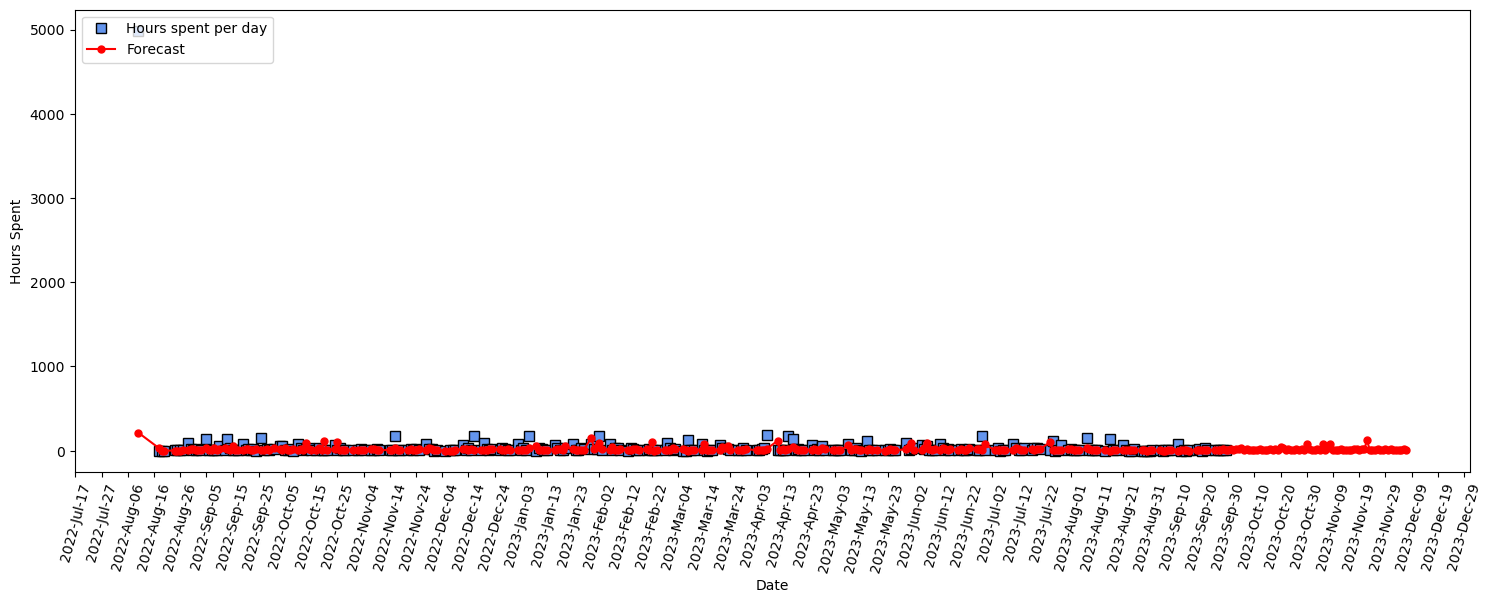

DP2
Period: 6
Initial Level: 13.059718997108586
Initial Trend: 0.0017066143370020603
Initial Seasonal: [0.9941125883856231, 0.9869708078310974, 1.0023848531518322, 0.9957843847035978, 1.0006925214615523, 1.0065726047061645]
           TEAMNAME  USERCOUNT  SECONDSSPENT  QUANTITY      VOLUME  \
2023-09-23      DP2        1.0      227385.0       0.0    0.000000   
2023-09-25      DP2       43.0      454060.0  263427.0  843.574123   
2023-09-26      DP2       46.0      633332.0  204334.0  736.125066   
2023-09-27      DP2       46.0      611887.0  261812.0  893.401181   
2023-09-28      DP2       47.0      634110.0  220623.0  749.615969   
2023-09-29      DP2       46.0      735097.0  255841.0  865.942699   
2023-09-30      NaN        NaN           NaN       NaN         NaN   
2023-10-01      NaN        NaN           NaN       NaN         NaN   
2023-10-02      NaN        NaN           NaN       NaN         NaN   
2023-10-03      NaN        NaN           NaN       NaN         NaN   
2023-1

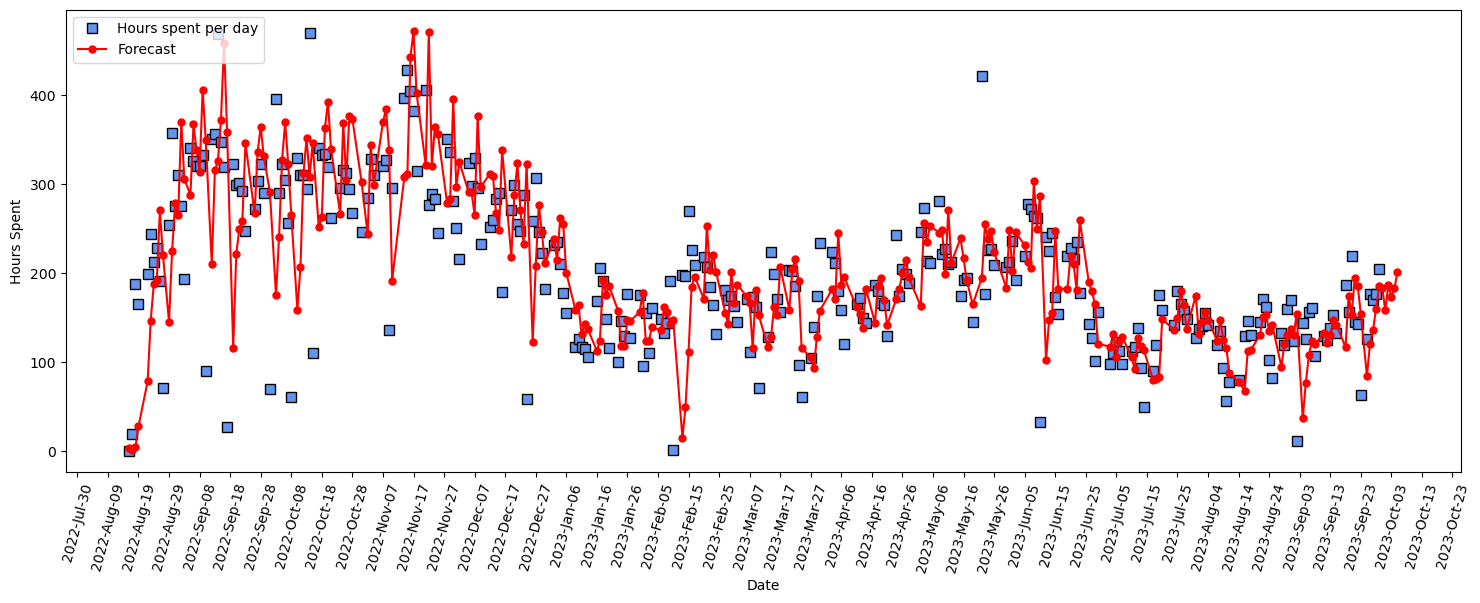

DP1
Period: 6
Initial Level: 13.446165447503985
Initial Trend: 0.00032672274154317105
Initial Seasonal: [0.999126130673534, 1.0046522889636111, 1.000452004193914, 0.9942608941797977, 0.992958413167489, 1.001754224643282]
           TEAMNAME  USERCOUNT  SECONDSSPENT  QUANTITY       VOLUME  \
2023-09-22      DP1       50.0      689214.0  282064.0   864.232672   
2023-09-25      DP1       51.0      698325.0  297376.0  1028.960877   
2023-09-26      DP1       55.0      576097.0  388098.0  1263.035686   
2023-09-27      DP1       53.0      621429.0  338778.0  1056.608685   
2023-09-28      DP1       53.0      670896.0  398947.0  1365.085042   
2023-09-29      DP1       50.0      629794.0  386483.0  1182.841185   
2023-09-30      NaN        NaN           NaN       NaN          NaN   
2023-10-01      NaN        NaN           NaN       NaN          NaN   
2023-10-02      NaN        NaN           NaN       NaN          NaN   
2023-10-03      NaN        NaN           NaN       NaN          NaN  

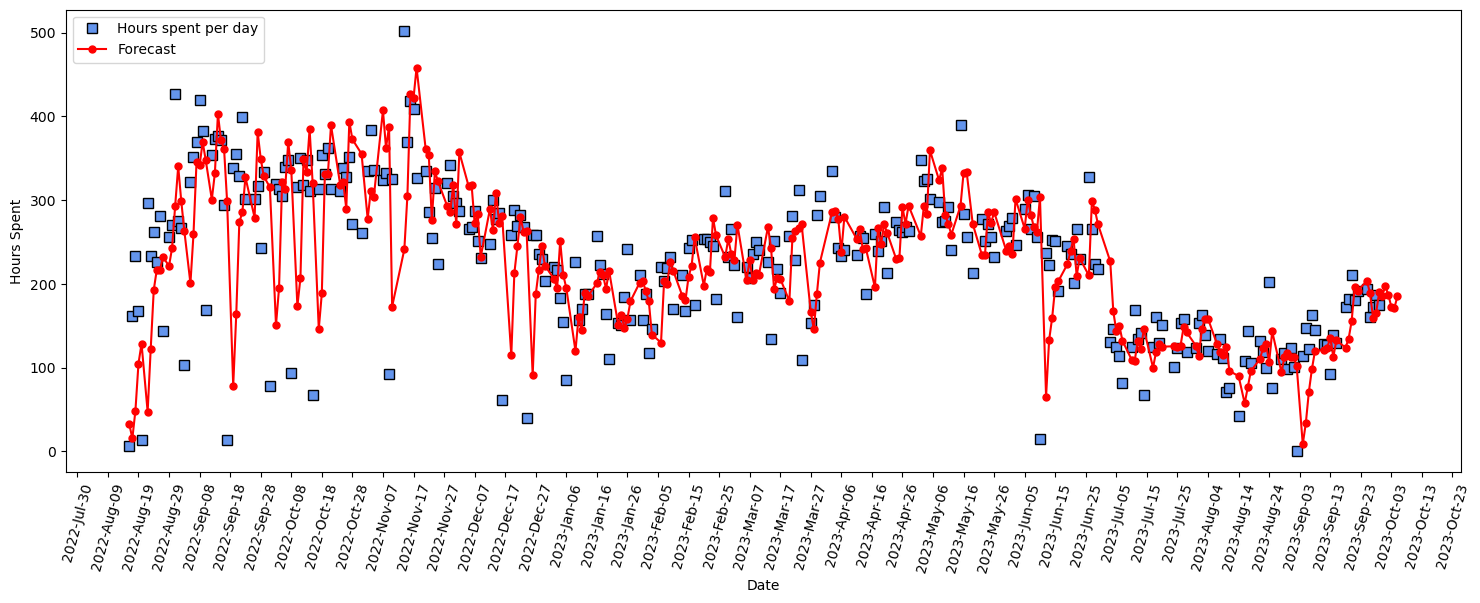

HP1
Period: 7
Initial Level: 7.558660266558329
Initial Trend: 0.00167915374543856
Initial Seasonal: [0.9992786894573648, 0.9881355654723046, 1.0095895887313195, 0.991912265612759, 1.0091535996524277, 1.005279875717185, 0.9890506927057737]
           TEAMNAME  USERCOUNT  SECONDSSPENT  QUANTITY      VOLUME  \
2023-09-20      HP1        1.0        2653.0   31217.0  109.952600   
2023-09-21      HP1        1.0        2465.0   49427.0  141.002733   
2023-09-22      HP1        1.0        1323.0   20521.0   70.522329   
2023-09-26      HP1        1.0        2926.0   57558.0  339.941762   
2023-09-27      HP1        1.0         889.0   53843.0  133.876221   
2023-09-28      HP1        1.0         275.0   19455.0   73.001879   
2023-09-29      HP1        1.0         784.0   46145.0  127.654466   
2023-09-30      NaN        NaN           NaN       NaN         NaN   
2023-10-01      NaN        NaN           NaN       NaN         NaN   
2023-10-02      NaN        NaN           NaN       NaN       

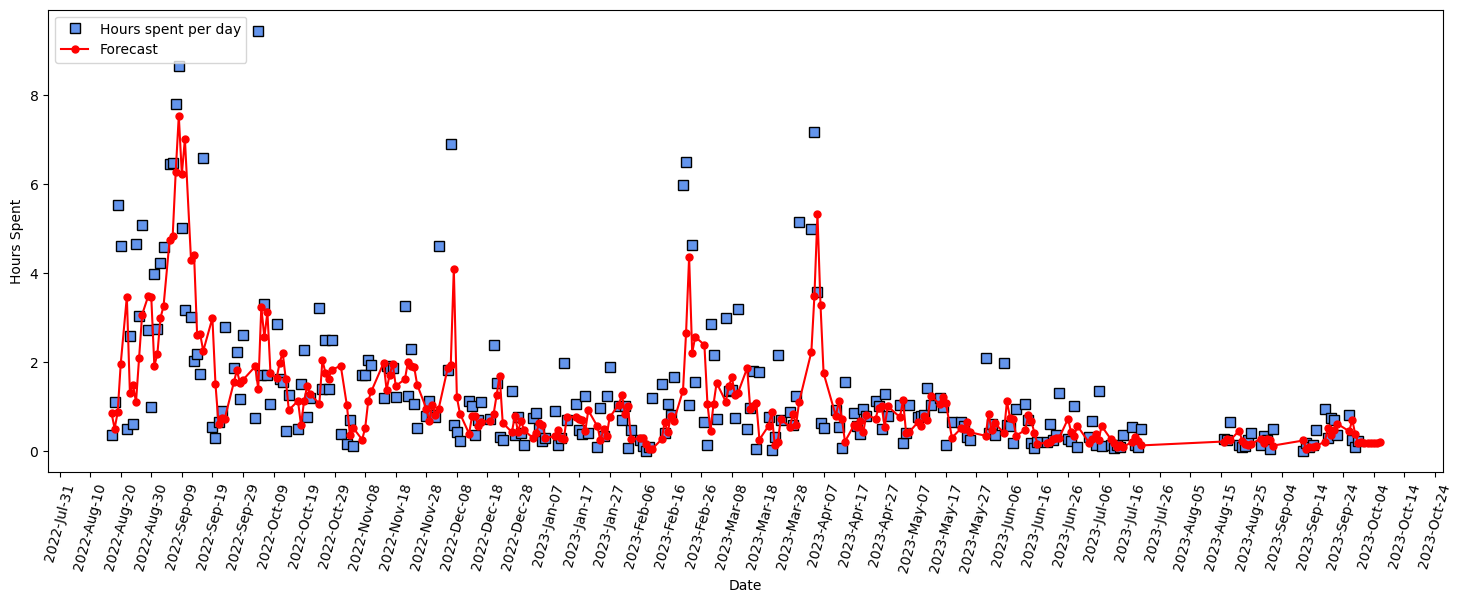

HP2
Period: 4
Initial Level: 9.074239956480161
Initial Trend: 0.0003643819391341215
Initial Seasonal: [1.004866145835956, 1.0128441439773563, 0.9952722805195648, 0.98944870548778]
           TEAMNAME  USERCOUNT  SECONDSSPENT  QUANTITY      VOLUME  \
2023-09-26      HP2        3.0        7178.0   96688.0  294.472257   
2023-09-27      HP2        2.0        6901.0   88725.0  298.403905   
2023-09-28      HP2        2.0        5959.0  144051.0  408.675710   
2023-09-29      HP2        3.0        9210.0   88845.0  288.663179   
2023-09-30      NaN        NaN           NaN       NaN         NaN   
2023-10-01      NaN        NaN           NaN       NaN         NaN   
2023-10-02      NaN        NaN           NaN       NaN         NaN   
2023-10-03      NaN        NaN           NaN       NaN         NaN   

                  WEIGHT      PRICE     FORECAST  
2023-09-26  31676.818667  188791.38  2512.623862  
2023-09-27  28754.759333  190851.16  3786.480450  
2023-09-28  41282.237833  246956.96 

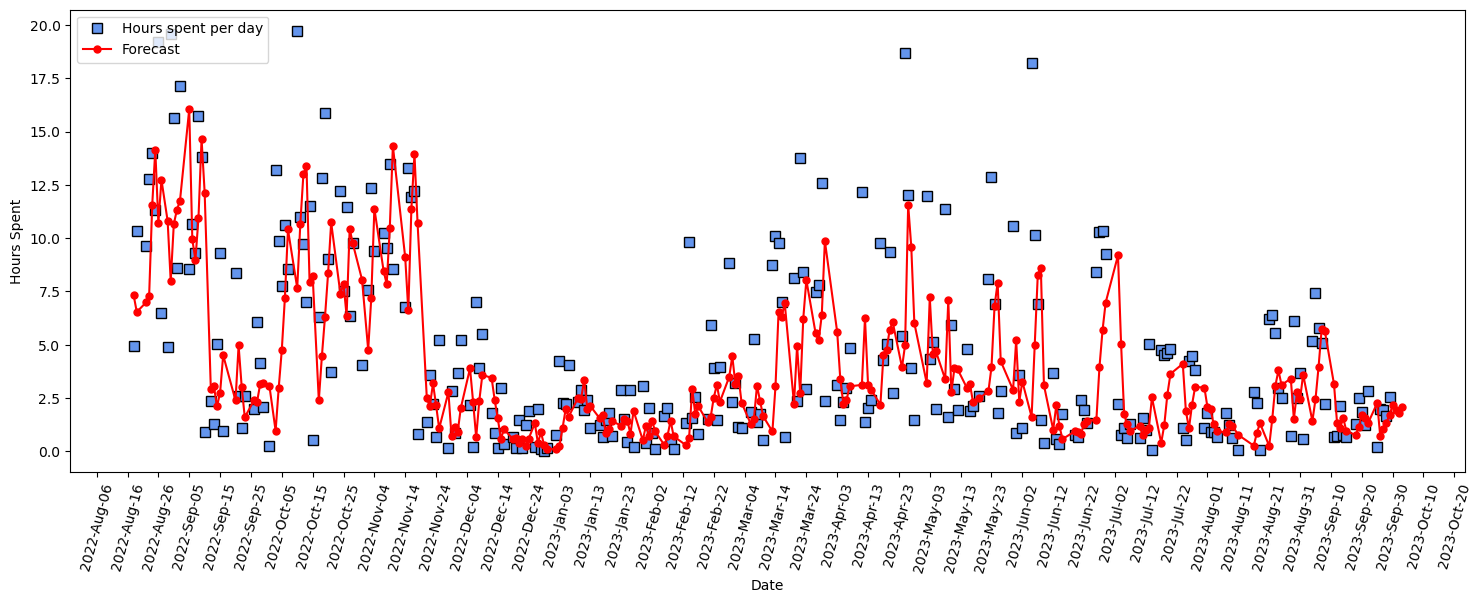

HD
No seasonality found
Period: 1
Initial Level: 8.210653429242567
Initial Trend: 0.006055143622597945
Initial Seasonal: [1]
           TEAMNAME  USERCOUNT  SECONDSSPENT  QUANTITY      VOLUME  \
2023-05-03       HD        1.0        6590.0   40190.0  232.794156   
2023-05-04      NaN        NaN           NaN       NaN         NaN   

                 WEIGHT       PRICE     FORECAST  
2023-05-03  24641.46114  1520145.54  3945.030606  
2023-05-04          NaN         NaN  4911.614434  
MAE: 0.653


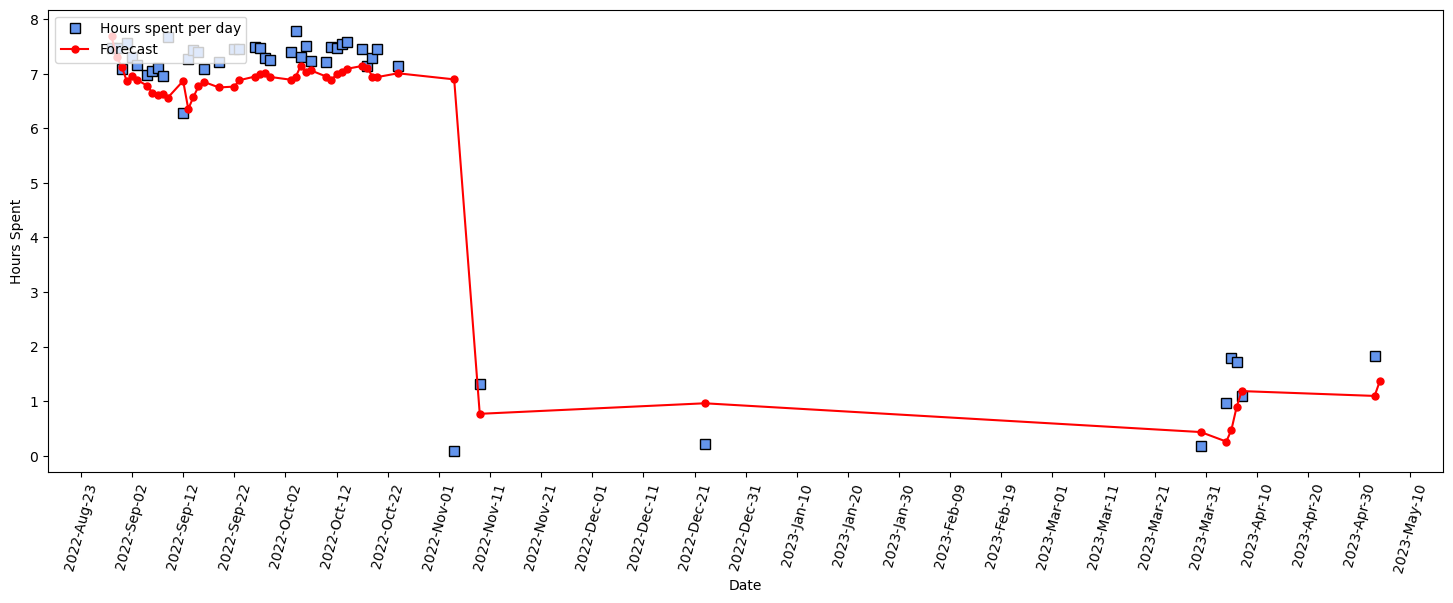

In [194]:
df = pd.read_csv('daily.csv')
df.index = [datetime.strptime(x, '%Y-%m-%d') for x in df['DATE']]
df.drop('DATE', axis=1, inplace=True)
df = df[df.index >= '2022-08-10']
column = 'SECONDSSPENT'
# df = df[df['TEAMNAME'] == 'DP1']
print(0 in df[column].to_list())
for team in df['TEAMNAME'].unique():
    df_team = df[df['TEAMNAME'] == team]
    if len(df_team) > 1:
        print(team)
        plot_forecast(df_team, column, team)